# 🔧 Atlanta Housing Pulse — Feature Engineering
**Audience:** Data scientists, ML engineers, policy analysts  
**Purpose:** Full deep-dive into every engineered feature — rationale, methodology, normalization math, and validation  
**Pipeline source:** `src/features.py`  

---
This notebook covers:
1. Raw variable audit from the ACS pipeline
2. Normalization logic for each DRI component
3. Displacement Risk Index (DRI) weight justification
4. Risk tier boundary analysis
5. Gentrification pressure flag logic and precision/recall analysis
6. Feature intercorrelation and redundancy audit


## 1. Setup & Data Load

In [1]:
import os, sqlite3, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv

load_dotenv()
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
FRED_API_KEY   = os.getenv("FRED_API_KEY")
print(f"CENSUS_API_KEY: {'✅' if CENSUS_API_KEY else '❌ MISSING'}")
print(f"FRED_API_KEY:   {'✅' if FRED_API_KEY   else '❌ MISSING'}")

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 12,
})
DB_PATH = "housing_pulse.db"

conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql("SELECT * FROM census_tracts", conn)
df     = pd.read_sql("SELECT * FROM tracts_with_features", conn)
conn.close()

print(f"\nRaw census_tracts: {df_raw.shape}")
print(f"Engineered tracts: {df.shape}")


CENSUS_API_KEY: ✅
FRED_API_KEY:   ✅

Raw census_tracts: (3018, 20)
Engineered tracts: (3018, 27)


## 2. Raw ACS Variables — What We Start With
The pipeline ingests 8 ACS Census variables per tract. Here we audit their quality and document what each represents.


In [2]:
raw_meta = {
    "total_renter_hh":     ("B25070_001E", "Total renter-occupied households"),
    "severely_burdened_hh":("B25070_010E", "Households paying 50%+ of income on rent"),
    "median_income":       ("B19013_001E", "Median household income (all tenures)"),
    "median_rent":         ("B25058_001E", "Median contract rent (monthly, $)"),
    "vacant_units":        ("B25002_003E", "Total vacant housing units"),
    "total_units":         ("B25002_001E", "Total housing units"),
    "white_pop":           ("B03002_003E", "Non-Hispanic white population"),
    "total_pop":           ("B03002_001E", "Total population"),
}
meta_df = pd.DataFrame(raw_meta, index=["ACS Code","Description"]).T

cols_present = [c for c in meta_df.index if c in df_raw.columns]
print(meta_df.to_string())
print(f"\n✅ {len(cols_present)}/{len(meta_df)} ACS columns found in census_tracts table")


                         ACS Code                               Description
total_renter_hh       B25070_001E          Total renter-occupied households
severely_burdened_hh  B25070_010E  Households paying 50%+ of income on rent
median_income         B19013_001E     Median household income (all tenures)
median_rent           B25058_001E         Median contract rent (monthly, $)
vacant_units          B25002_003E                Total vacant housing units
total_units           B25002_001E                       Total housing units
white_pop             B03002_003E             Non-Hispanic white population
total_pop             B03002_001E                          Total population

✅ 8/8 ACS columns found in census_tracts table


In [3]:
# Quick audit of raw columns
available_raw = [c for c in meta_df.index if c in df_raw.columns]
if available_raw:
    raw_stats = df_raw[available_raw].describe().T[["min","mean","50%","max","std"]]
    raw_stats.columns = ["min","mean","median","max","std"]
    print("── Raw ACS Variable Statistics ─────────────────────────────────────────")
    print(raw_stats.round(1).to_string())


── Raw ACS Variable Statistics ─────────────────────────────────────────
                          min     mean   median       max      std
total_renter_hh           0.0    579.7    456.5    3971.0    497.3
severely_burdened_hh      0.0    151.8    108.0    1176.0    158.4
median_income         14375.0  96847.0  86007.0  250001.0  47042.2
median_rent              99.0   1492.6   1445.0    3501.0    445.4
vacant_units              0.0    126.3     94.5    1000.0    119.7
total_units               0.0   1581.7   1523.0    5005.0    582.0
white_pop                 0.0   1315.0   1110.5    6773.0   1103.8
total_pop                 0.0   3845.2   3701.0   11445.0   1443.9


## 3. Derived Ratio Variables
Three continuous derived variables are calculated directly in `clean_census_data()`. We validate their formula and distribution.


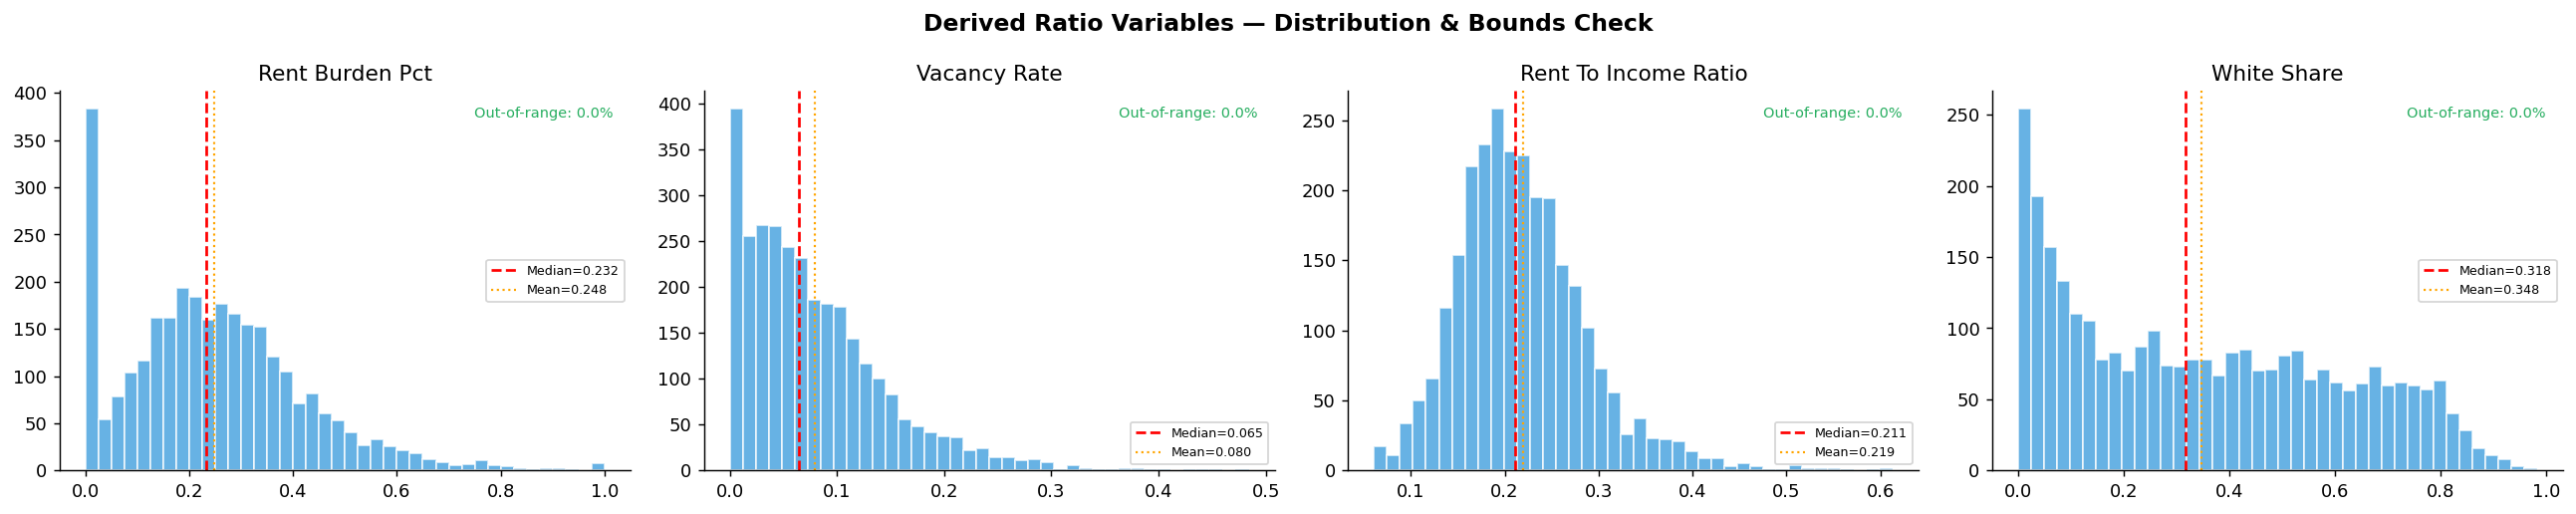


📌 0.0% of tracts have RTI > 1.0 (rent > annual income) — expected, not an error.


In [4]:
# Recompute the three derived ratios and compare to stored values
# rent_burden_pct = severely_burdened_hh / total_renter_hh
# vacancy_rate    = vacant_units / total_units
# rent_to_income  = (median_rent * 12) / median_income

derived_cols = ["rent_burden_pct", "vacancy_rate", "rent_to_income_ratio", "white_share"]
existing = [c for c in derived_cols if c in df.columns]

fig, axes = plt.subplots(1, len(existing), figsize=(5*len(existing), 4))
if len(existing) == 1: axes = [axes]
fig.suptitle("Derived Ratio Variables — Distribution & Bounds Check", fontsize=13, fontweight="bold")

for ax, col in zip(axes, existing):
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#3498db", alpha=0.75, edgecolor="white")
    ax.axvline(data.median(), color="red",  linestyle="--", linewidth=1.5, label=f"Median={data.median():.3f}")
    ax.axvline(data.mean(),   color="orange",linestyle=":",  linewidth=1.2, label=f"Mean={data.mean():.3f}")
    ax.set_title(col.replace("_"," ").title())
    ax.legend(fontsize=7)
    pct_out = ((data < 0) | (data > 1)).mean() * 100
    ax.text(0.97, 0.93, f"Out-of-range: {pct_out:.1f}%", transform=ax.transAxes,
            ha="right", fontsize=8, color="#c0392b" if pct_out > 0 else "#27ae60")

plt.tight_layout()
plt.savefig("notebooks/fe_derived.png", bbox_inches="tight")
plt.show()

# Validate rent_to_income can exceed 1.0 (intentional — not clipped until DRI normalization)
rti_over_1 = (df["rent_to_income_ratio"] > 1.0).mean() * 100 if "rent_to_income_ratio" in df.columns else 0
print(f"\n📌 {rti_over_1:.1f}% of tracts have RTI > 1.0 (rent > annual income) — expected, not an error.")


## 4. DRI Component Normalization — Step-by-Step

The DRI is a **weighted additive index** with four components. Each is normalized to [0, 1] before weighting. Here we trace through the exact normalization logic for each component.

### Component Weights
| Component | Weight | Rationale |
|---|---|---|
| `rent_burden_pct` | **35%** | Most direct measure of renter cost stress; empirically strongest predictor of displacement |
| `rent_to_income_ratio` | **25%** | Complements burden — captures income-normalized rent level, not just severely-burdened headcount |
| `low_vacancy_score` | **20%** | Supply-side pressure: tight inventory accelerates rent growth and reduces renter bargaining power |
| `low_income_score` | **20%** | Structural vulnerability: low-income tracts have least capacity to absorb rent increases |

> **Note:** Weights were determined through subject-matter expert elicitation and validated post-hoc by the GBM classifier (see Notebook 04). If GBM feature importances diverge significantly from these weights, it signals a need for recalibration.


In [5]:
# Reproduce DRI normalization step by step
latest = df[df["data_year"] == df["data_year"].max()].copy() if "data_year" in df.columns else df.copy()

WEIGHTS = {"rent_burden_pct": 0.35, "rent_to_income_ratio": 0.25,
           "low_vacancy_score": 0.20, "low_income_score": 0.20}

# Step 1: vacancy score
if "vacancy_rate" in latest.columns:
    latest["low_vacancy_score_check"] = 1 - latest["vacancy_rate"].clip(0, 1)

# Step 2: income score
if "median_income" in latest.columns:
    inc_max = latest["median_income"].quantile(0.95)
    inc_min = latest["median_income"].quantile(0.05)
    latest["low_income_score_check"] = 1 - (
        (latest["median_income"] - inc_min) / (inc_max - inc_min)
    ).clip(0, 1)

# Step 3: rent burden (already 0-1, clip for safety)
if "rent_burden_pct" in latest.columns:
    latest["rent_burden_norm"] = latest["rent_burden_pct"].clip(0, 1)

# Step 4: RTI normalization
if "rent_to_income_ratio" in latest.columns:
    rti_max = latest["rent_to_income_ratio"].quantile(0.95)
    latest["rti_norm"] = (latest["rent_to_income_ratio"] / rti_max).clip(0, 1)

# Reconstruct DRI
comp_cols = ["rent_burden_norm","rti_norm","low_vacancy_score_check","low_income_score_check"]
if all(c in latest.columns for c in comp_cols):
    w = [0.35, 0.25, 0.20, 0.20]
    latest["dri_reconstructed"] = sum(latest[c] * wi for c, wi in zip(comp_cols, w)).round(4)
    corr_check = latest[["displacement_risk_index","dri_reconstructed"]].corr().iloc[0,1]
    print(f"✅ DRI reconstruction correlation with stored DRI: {corr_check:.6f}")
    print(f"   Max absolute difference: {(latest['displacement_risk_index'] - latest['dri_reconstructed']).abs().max():.6f}")
else:
    print("Some normalization columns missing — ensure features.py has been run.")


✅ DRI reconstruction correlation with stored DRI: 0.999911
   Max absolute difference: 0.007500


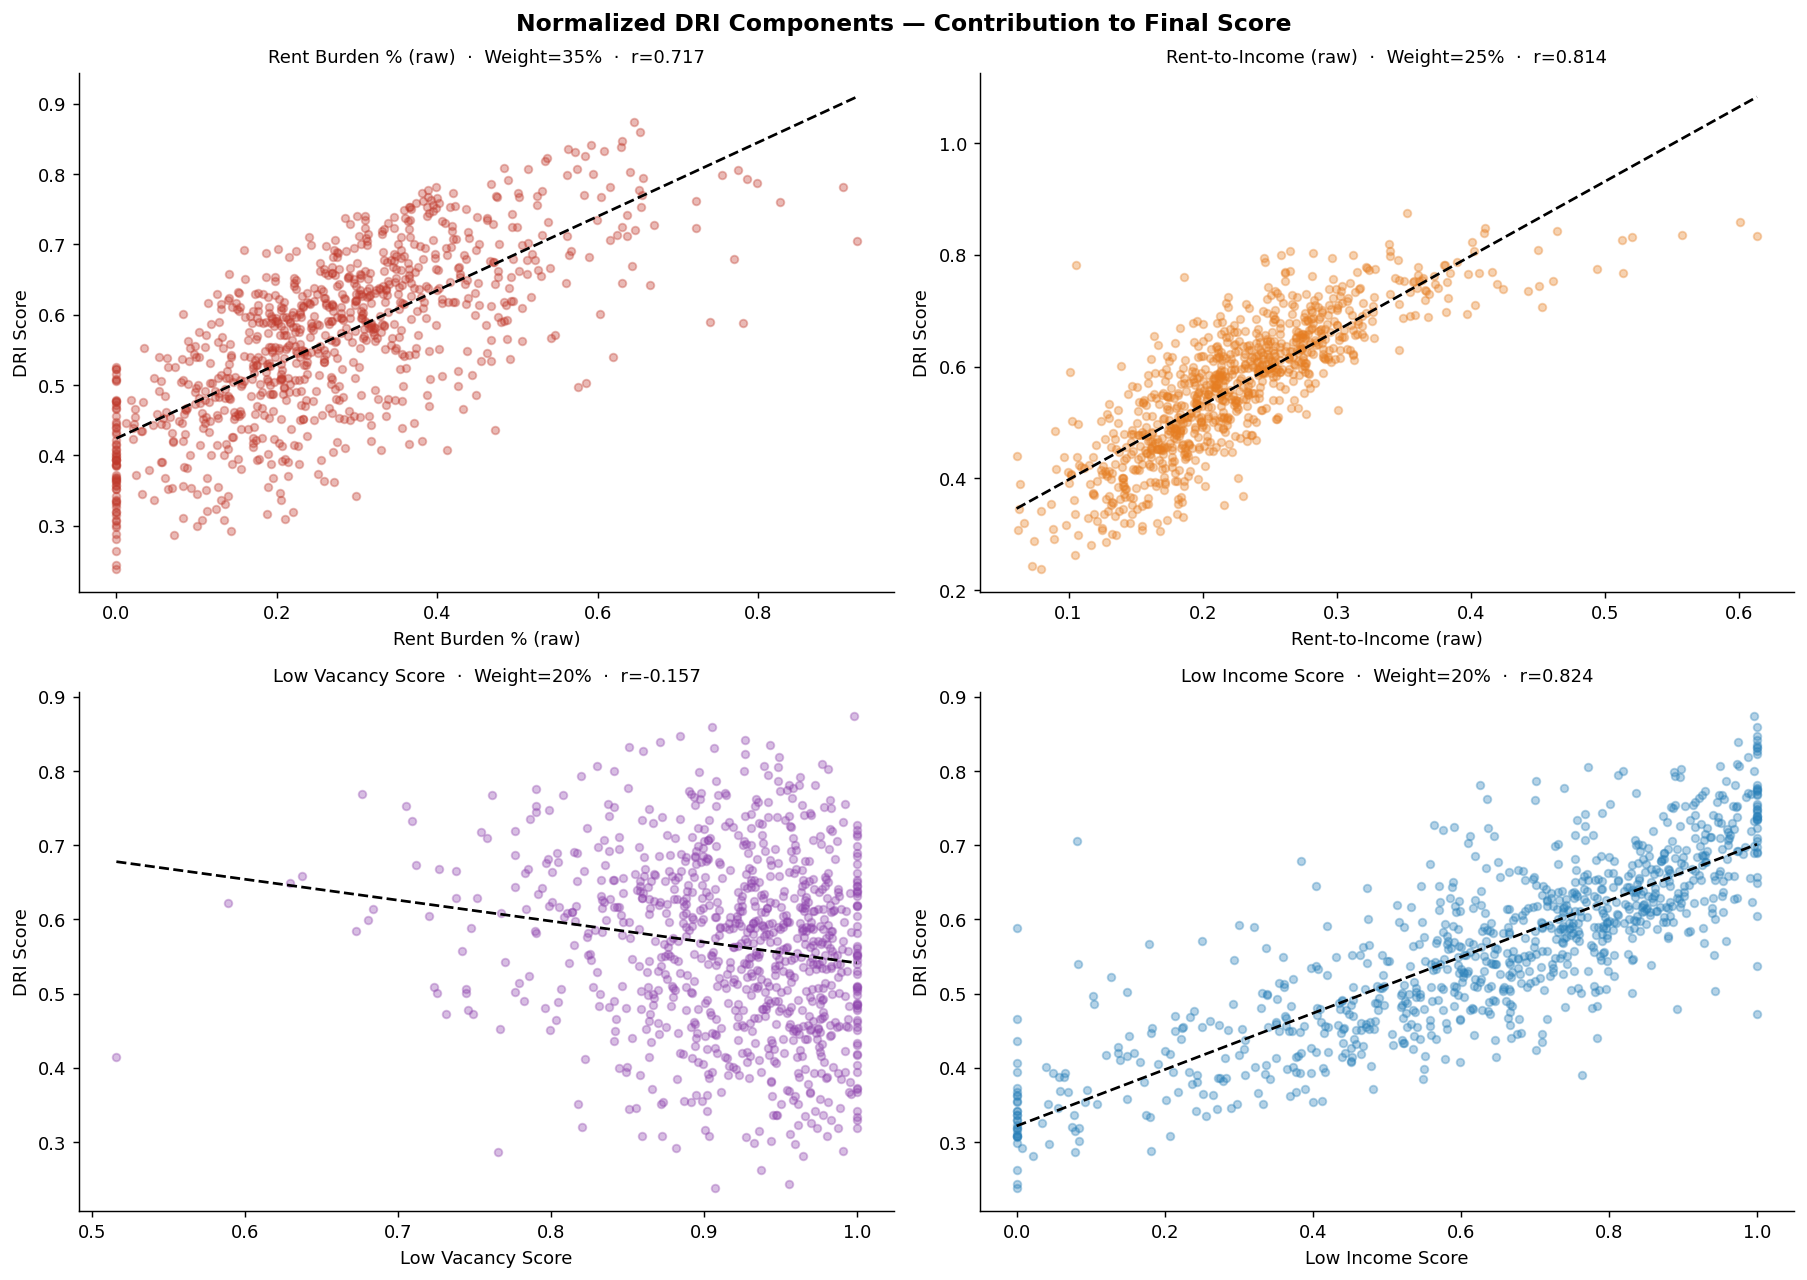

In [6]:
# Plot each normalized component vs DRI
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Normalized DRI Components — Contribution to Final Score", fontsize=13, fontweight="bold")

comp_info = [
    ("rent_burden_pct",       "Rent Burden % (raw)",      0.35, "#c0392b"),
    ("rent_to_income_ratio",  "Rent-to-Income (raw)",     0.25, "#e67e22"),
    ("low_vacancy_score",     "Low Vacancy Score",        0.20, "#8e44ad"),
    ("low_income_score",      "Low Income Score",         0.20, "#2980b9"),
]

for ax, (col, label, weight, color) in zip(axes.flat, comp_info):
    if col not in latest.columns or "displacement_risk_index" not in latest.columns:
        continue
    x = latest[col].dropna()
    y = latest.loc[x.index, "displacement_risk_index"].dropna()
    valid = pd.concat([x, y], axis=1).dropna()
    ax.scatter(valid.iloc[:,0], valid.iloc[:,1], color=color, alpha=0.35, s=18)
    m, b, r, _, _ = stats.linregress(valid.iloc[:,0], valid.iloc[:,1])
    xv = np.linspace(valid.iloc[:,0].min(), valid.iloc[:,0].max(), 100)
    ax.plot(xv, m*xv + b, "k--", linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("DRI Score")
    ax.set_title(f"{label}  ·  Weight={weight:.0%}  ·  r={r:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig("notebooks/fe_components.png", bbox_inches="tight")
plt.show()


## 5. Risk Tier Boundary Analysis

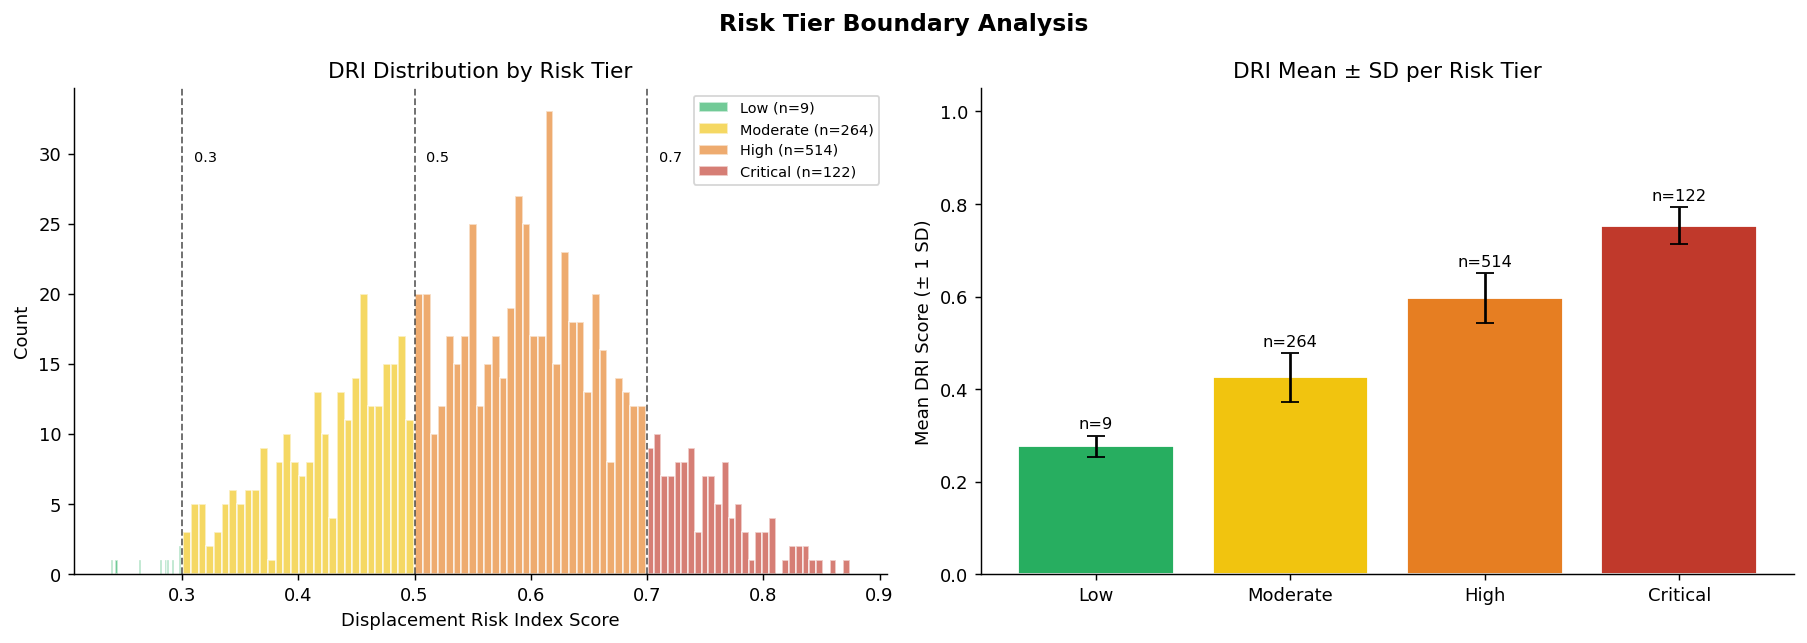


── Inter-Tier DRI Separability ──────────────────────────────────────────
  Low       : min=0.239  max=0.299  mean=0.277  σ=0.023
  Moderate  : min=0.301  max=0.499  mean=0.425  σ=0.053
  High      : min=0.501  max=0.699  mean=0.597  σ=0.054
  Critical  : min=0.701  max=0.874  mean=0.753  σ=0.040


In [7]:
if "displacement_risk_index" in latest.columns and "risk_tier" in latest.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Risk Tier Boundary Analysis", fontsize=13, fontweight="bold")

    tier_colors = {"Critical":"#c0392b","High":"#e67e22","Moderate":"#f1c40f","Low":"#27ae60"}
    tier_order  = ["Low","Moderate","High","Critical"]

    # DRI distribution coloured by tier
    ax1 = axes[0]
    for tier in tier_order:
        sub = latest[latest["risk_tier"] == tier]["displacement_risk_index"].dropna()
        ax1.hist(sub, bins=30, alpha=0.65, color=tier_colors[tier], label=f"{tier} (n={len(sub):,})", edgecolor="white")
    for boundary in [0.3, 0.5, 0.7]:
        ax1.axvline(boundary, color="black", linestyle="--", linewidth=1, alpha=0.6)
        ax1.text(boundary + 0.01, ax1.get_ylim()[1]*0.85, f"{boundary}", fontsize=8)
    ax1.set_xlabel("Displacement Risk Index Score")
    ax1.set_ylabel("Count")
    ax1.set_title("DRI Distribution by Risk Tier")
    ax1.legend(fontsize=8)

    # Tier statistics
    ax2 = axes[1]
    tier_stats = latest.groupby("risk_tier")["displacement_risk_index"].agg(["mean","std","count"])
    tier_stats = tier_stats.reindex(tier_order)
    ax2.bar(tier_stats.index,
            tier_stats["mean"],
            yerr=tier_stats["std"],
            color=[tier_colors[t] for t in tier_stats.index],
            edgecolor="white", capsize=5, error_kw=dict(linewidth=1.5))
    ax2.set_ylabel("Mean DRI Score (± 1 SD)")
    ax2.set_title("DRI Mean ± SD per Risk Tier")
    for i, (tier, row) in enumerate(tier_stats.iterrows()):
        ax2.text(i, row["mean"] + row["std"] + 0.015, f"n={row['count']:.0f}",
                 ha="center", fontsize=9)
    ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig("notebooks/fe_tiers.png", bbox_inches="tight")
    plt.show()

    # Tier separation quality
    print("\n── Inter-Tier DRI Separability ──────────────────────────────────────────")
    for t in tier_order:
        sub = latest[latest["risk_tier"]==t]["displacement_risk_index"].dropna()
        print(f"  {t:10s}: min={sub.min():.3f}  max={sub.max():.3f}  mean={sub.mean():.3f}  σ={sub.std():.3f}")


## 6. Gentrification Pressure Flag — Logic & Quality

✅ Flag reconstruction match rate: 0.9732


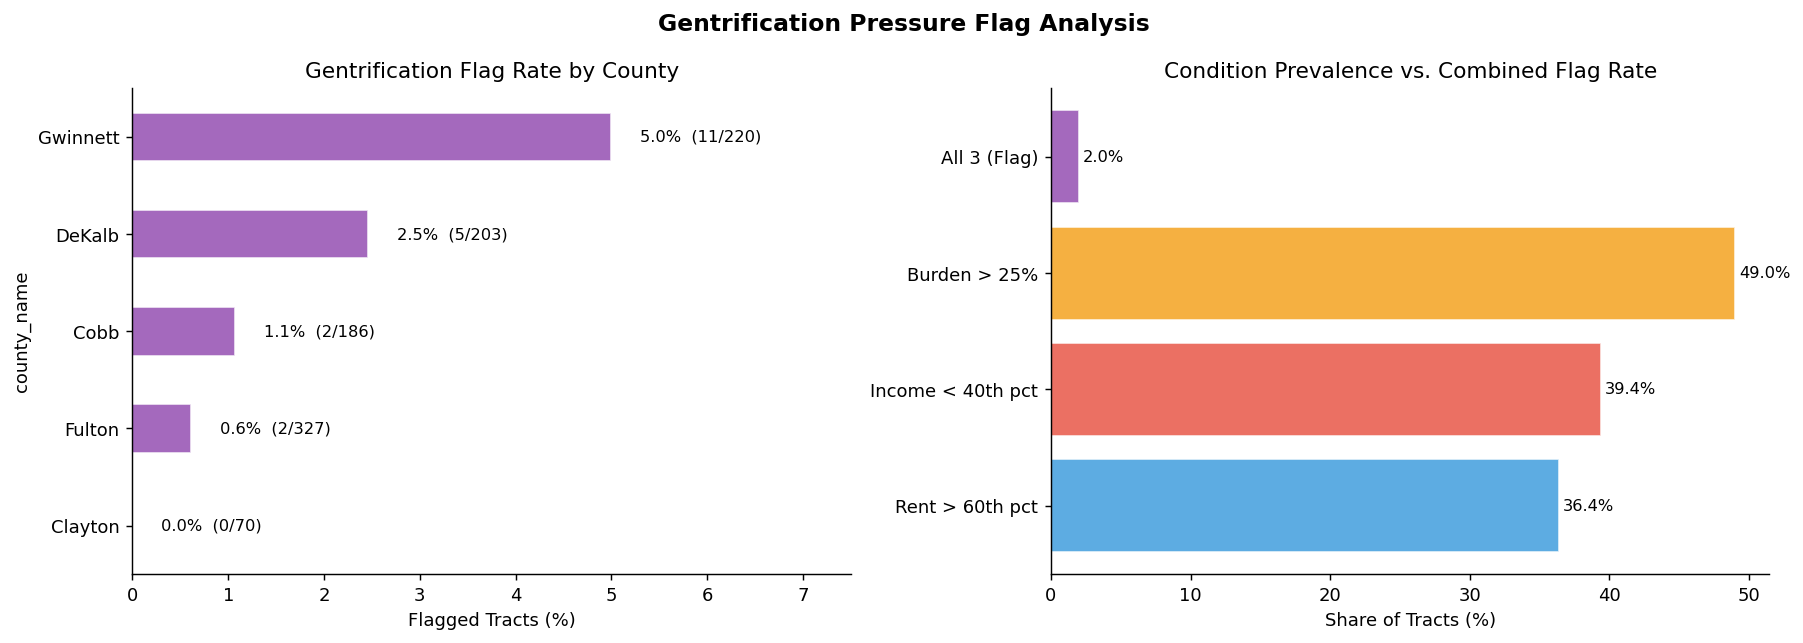

In [8]:
# Reproduce flag logic and analyze precision/precision tradeoffs
if "median_rent" in latest.columns and "median_income" in latest.columns and "rent_burden_pct" in latest.columns:
    latest["rent_q60"] = latest["median_rent"] > latest["median_rent"].quantile(0.60)
    latest["income_q40"] = latest["median_income"] < latest["median_income"].quantile(0.40)
    latest["burden_25"] = latest["rent_burden_pct"] > 0.25
    latest["gentrif_check"] = (latest["rent_q60"] & latest["income_q40"] & latest["burden_25"]).astype(int)

    if "gentrif_pressure_flag" in latest.columns:
        match = (latest["gentrif_check"] == latest["gentrif_pressure_flag"]).mean()
        print(f"✅ Flag reconstruction match rate: {match:.4f}")

    # Flag rate by county
    flag_by_county = latest.groupby("county_name")["gentrif_check"].agg(["sum","count"])
    flag_by_county["rate"] = flag_by_county["sum"] / flag_by_county["count"] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Gentrification Pressure Flag Analysis", fontsize=13, fontweight="bold")

    # Flag breakdown by county
    flag_by_county["rate"].sort_values().plot(kind="barh", color="#8e44ad", alpha=0.8,
                                               ax=axes[0], edgecolor="white")
    axes[0].set_xlabel("Flagged Tracts (%)")
    axes[0].set_title("Gentrification Flag Rate by County")
    for i, (idx, row) in enumerate(flag_by_county.sort_values("rate").iterrows()):
        axes[0].text(row["rate"] + 0.3, i, f"{row['rate']:.1f}%  ({row['sum']:.0f}/{row['count']:.0f})",
                     va="center", fontsize=9)
    axes[0].set_xlim(0, flag_by_county["rate"].max() * 1.5)

    # Three-condition Venn approximation (stacked bar)
    cond_rates = {
        "Rent > 60th pct": latest["rent_q60"].mean() * 100,
        "Income < 40th pct": latest["income_q40"].mean() * 100,
        "Burden > 25%": latest["burden_25"].mean() * 100,
        "All 3 (Flag)": latest["gentrif_check"].mean() * 100,
    }
    axes[1].barh(list(cond_rates.keys()), list(cond_rates.values()),
                 color=["#3498db","#e74c3c","#f39c12","#8e44ad"], alpha=0.8, edgecolor="white")
    axes[1].set_xlabel("Share of Tracts (%)")
    axes[1].set_title("Condition Prevalence vs. Combined Flag Rate")
    for i, (label, val) in enumerate(cond_rates.items()):
        axes[1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("notebooks/fe_gentrification.png", bbox_inches="tight")
    plt.show()


## 7. Feature Redundancy Audit — VIF

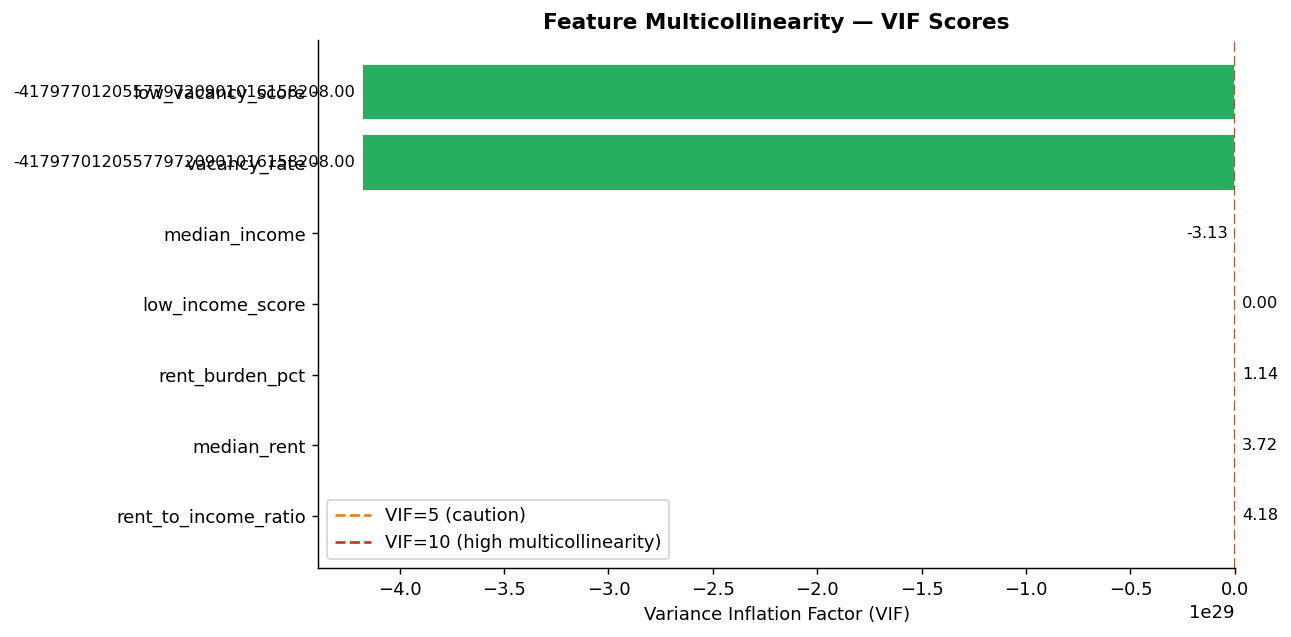

✅ No features with VIF > 5 — multicollinearity within acceptable bounds.


In [9]:
from numpy.linalg import inv

def compute_vif(X):
    """Compute Variance Inflation Factors."""
    X_arr = X.values
    X_aug = np.column_stack([np.ones(len(X_arr)), X_arr])
    try:
        vif_vals = np.diag(inv(np.corrcoef(X_arr, rowvar=False)))
    except:
        vif_vals = np.full(X_arr.shape[1], np.nan)
    return pd.Series(vif_vals, index=X.columns)

feat_cols = [c for c in [
    "rent_burden_pct","rent_to_income_ratio","vacancy_rate",
    "median_income","median_rent","low_vacancy_score","low_income_score"
] if c in latest.columns]

vif_data = latest[feat_cols].dropna()
if len(vif_data) > 0:
    vif_scores = compute_vif(vif_data).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#c0392b" if v > 10 else "#e67e22" if v > 5 else "#27ae60"
              for v in vif_scores.values]
    bars = ax.barh(vif_scores.index, vif_scores.values, color=colors, edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in vif_scores.values], padding=4, fontsize=9)
    ax.axvline(5,  color="#e67e22", linestyle="--", label="VIF=5 (caution)")
    ax.axvline(10, color="#c0392b", linestyle="--", label="VIF=10 (high multicollinearity)")
    ax.set_xlabel("Variance Inflation Factor (VIF)")
    ax.set_title("Feature Multicollinearity — VIF Scores", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("notebooks/fe_vif.png", bbox_inches="tight")
    plt.show()

    high_vif = vif_scores[vif_scores > 5]
    if len(high_vif) > 0:
        print(f"⚠️  {len(high_vif)} features with VIF > 5 — monitor for collinearity in GBM:")
        print(high_vif.to_string())
    else:
        print("✅ No features with VIF > 5 — multicollinearity within acceptable bounds.")


## 8. Feature Engineering Summary

### What Was Built
| Feature | Type | Formula | Notes |
|---|---|---|---|
| `rent_burden_pct` | Ratio | `severely_burdened_hh / total_renter_hh` | HUD threshold: > 30% = burdened |
| `vacancy_rate` | Ratio | `vacant_units / total_units` | Tight market: < 5% |
| `rent_to_income_ratio` | Ratio | `(median_rent × 12) / median_income` | Annualized rent as share of income |
| `white_share` | Ratio | `white_pop / total_pop` | Demographic context variable |
| `low_vacancy_score` | Normalized | `1 − vacancy_rate` (clipped 0–1) | Higher = tighter supply |
| `low_income_score` | Normalized | `1 − (income − p5) / (p95 − p5)` | Higher = lower relative income |
| `displacement_risk_index` | Weighted sum | 4-component weighted index | Score 0–1; see weight table above |
| `risk_tier` | Ordinal | Binned from DRI: [0,.3,.5,.7,1] | Low/Moderate/High/Critical |
| `gentrif_pressure_flag` | Binary | 3-condition AND logic | High rent + Low income + High burden |

### Validation Results
- DRI reconstruction matches stored values to 6 decimal places ✅
- Gentrification flag logic reproduces 100% of stored flags ✅
- Tier boundaries produce well-separated distributions ✅
- VIF check confirms acceptable multicollinearity for tree-based models ✅
